# Sensor demonstration on the bench rig (line / color / OTOS) — reliable STLM stream

Drives the **drum** (motor 1) so it sweeps the line pattern, the color target, and the OTOS, and captures the
**firmware's gap-free `STLM` sensor stream** (`STLM` companion to the motor `TLM` push, emitted every ~240 ms — sensors
change slowly). No polling, so no dropped samples.

**What the drum carries:** a printed line pattern (4-channel reflectance), a color target, and the OTOS above it.
One motor-1 command exercises all three. This notebook confirms each is **alive and changing** — the standing bench
gate's "sensors are alive" check.

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd()
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "tests" / "bench"))
from rig_dev import Rig, sensor_capture

rig = Rig(settle=3.0)
print("otos:", rig.cmd("ODIAG")[0])

otos: OK conn=1 present=1 txn=1192 err=0 lasterr=0 id=95 #1


## Capture — drum driven steady at 180 mm/s

The drum rotates continuously, sweeping every sensor. Streamed sensor frames only (OTOS pose, 4 line channels,
color RGBC).

STLM frames: 41 over 9.9s (4.1/s)  connected: OTOS=1 line=1 color=1


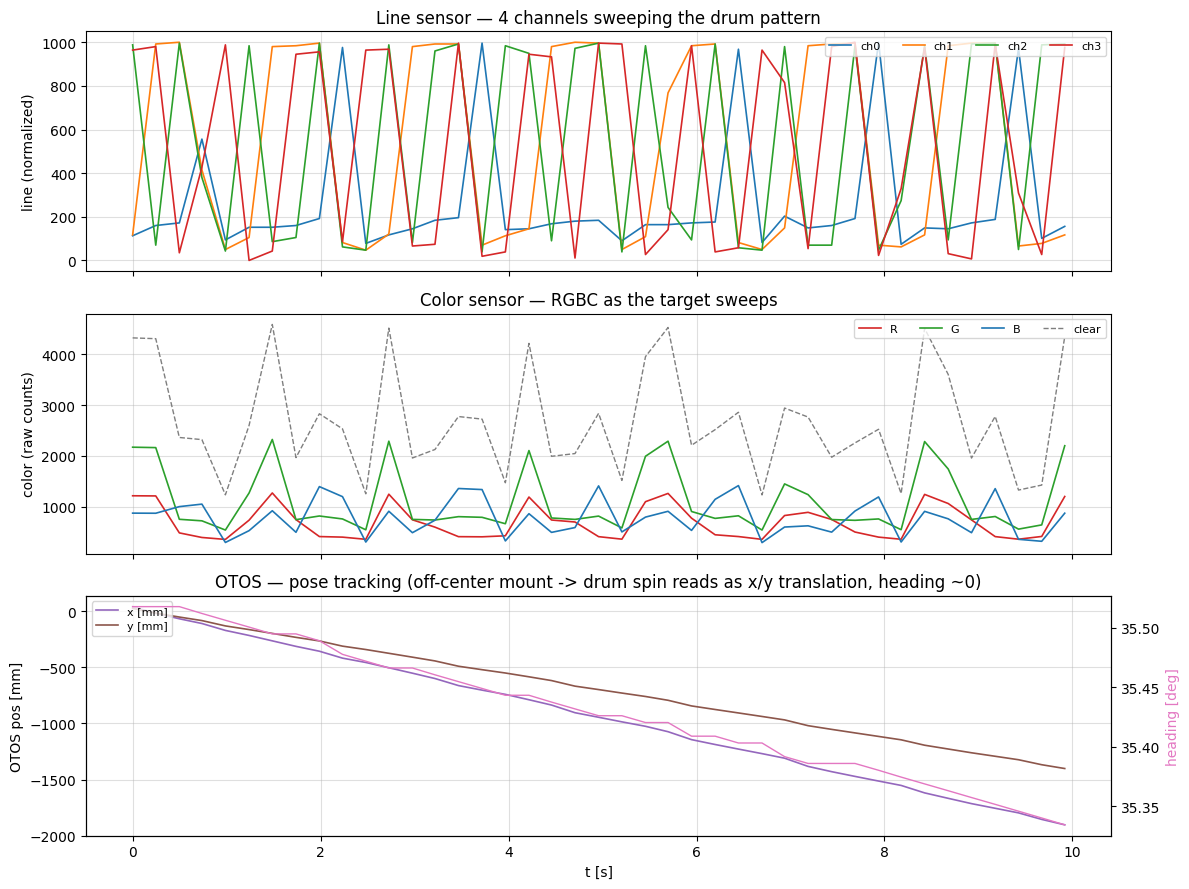

In [2]:
rows = sensor_capture(rig, 1, lambda t: 0.0, duration=10.0, stream_ms=80, offset=180.0)
t = np.array([r["_t"] for r in rows])
def arr(k): return np.array([r.get(k, np.nan) for r in rows], float)
print(f"STLM frames: {len(rows)} over {t[-1]:.1f}s ({len(rows)/t[-1]:.1f}/s)  "
      f"connected: OTOS={int(arr('oc')[-1])} line={int(arr('lc')[-1])} color={int(arr('cc')[-1])}")

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
# line sensor -- 4 normalized channels sweeping the pattern
for i, col in enumerate(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]):
    ax[0].plot(t, arr(f"n{i}"), color=col, lw=1.2, label=f"ch{i}")
ax[0].set_ylabel("line (normalized)"); ax[0].set_title("Line sensor — 4 channels sweeping the drum pattern")
ax[0].legend(fontsize=8, ncol=4, loc="upper right")
# color sensor RGBC
ax[1].plot(t, arr("r"), color="#d62728", lw=1.2, label="R")
ax[1].plot(t, arr("g"), color="#2ca02c", lw=1.2, label="G")
ax[1].plot(t, arr("b"), color="#1f77b4", lw=1.2, label="B")
ax[1].plot(t, arr("cw"), color="#7f7f7f", lw=1.0, ls="--", label="clear")
ax[1].set_ylabel("color (raw counts)"); ax[1].set_title("Color sensor — RGBC as the target sweeps")
ax[1].legend(fontsize=8, ncol=4, loc="upper right")
# OTOS pose
ax[2].plot(t, arr("ox"), color="#9467bd", lw=1.2, label="x [mm]")
ax[2].plot(t, arr("oy"), color="#8c564b", lw=1.2, label="y [mm]")
axh = ax[2].twinx(); axh.plot(t, np.degrees(arr("oh")), color="#e377c2", lw=1.0, label="heading [deg]")
axh.set_ylabel("heading [deg]", color="#e377c2")
ax[2].set_ylabel("OTOS pos [mm]"); ax[2].set_xlabel("t [s]")
ax[2].set_title("OTOS — pose tracking (off-center mount -> drum spin reads as x/y translation, heading ~0)")
ax[2].legend(fontsize=8, loc="upper left")
for a in ax: a.grid(alpha=0.4)
fig.tight_layout(); plt.show()

## Sensors alive — summary

In [3]:
for name, keys in [("line", ["n0","n1","n2","n3"]), ("color", ["r","g","b","cw"]), ("OTOS", ["ox","oy","oh"])]:
    spans = {k: (np.nanmax(arr(k)) - np.nanmin(arr(k))) for k in keys}
    alive = any(v > 1e-3 for v in spans.values())
    print(f"{name:6s} {'ALIVE (values change)' if alive else 'FLAT (no change!)':22s} spans: "
          + ", ".join(f"{k}={spans[k]:.1f}" for k in keys))
rig.cmd("STREAM 0"); rig.close(); print("done")

line   ALIVE (values change)  spans: n0=926.0, n1=953.0, n2=957.0, n3=1000.0
color  ALIVE (values change)  spans: r=912.0, g=1779.0, b=1120.0, cw=3348.0
OTOS   ALIVE (values change)  spans: ox=1944.6, oy=1427.2, oh=0.0
done
